In [3]:
# load libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [4]:
#load dataset --->Mnist
mnsit=fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
#numby array
X=mnsit.data
y=mnsit.target.astype(int)
#28*28 image,70000 images,flatten 
print(f"X shape: {X.shape}")      
print(f"y shape: {y.shape}")   
    

X shape: (70000, 784)
y shape: (70000,)


In [5]:
print(f"pixel range(intensity): black-->{X.min()} to white-->{X.max()}")
print(f"classes:{np.unique(y)}")
print(f"class distribution: {np.bincount(y)}")

pixel range(intensity): black-->0 to white-->255
classes:[0 1 2 3 4 5 6 7 8 9]
class distribution: [6903 7877 6990 7141 6824 6313 6876 7293 6825 6958]


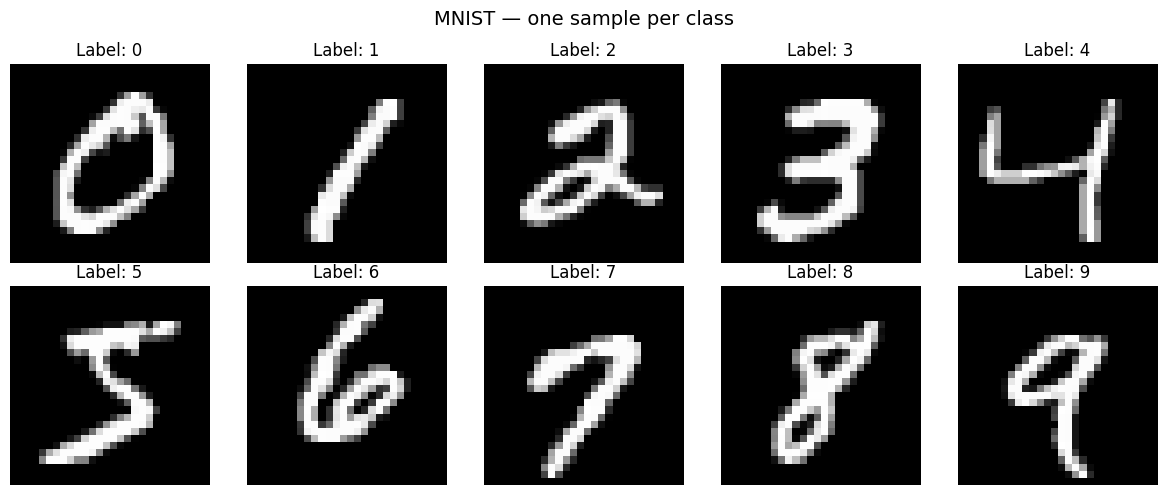

In [6]:
# Visualize 10 samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i,ax in enumerate(axes.flat):
    idx = np.where(y == i)[0][0]
    ax.imshow(X[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {i}')
    ax.axis('off')
plt.suptitle('MNIST — one sample per class', fontsize=14)
plt.tight_layout()
plt.savefig('../results/mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()

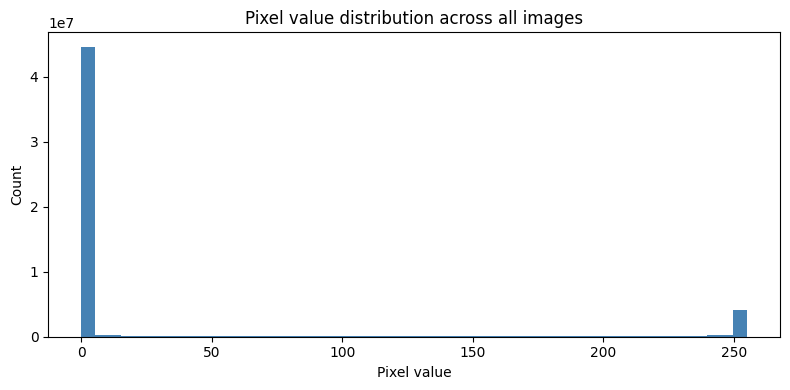

In [7]:
# Pixel distribution
plt.figure(figsize=(8, 4))
plt.hist(X.flatten(), bins=50, color='steelblue', edgecolor='none')
plt.xlabel('Pixel value')
plt.ylabel('Count')
plt.title('Pixel value distribution across all images')
plt.tight_layout()
plt.show()

## data_preprocessing

In [8]:
# Normalize pixels to [0, 1]
X = X / 255.0
#one_hote encoding to the labels
def one_hot(y,n_classes=10):
    # y: (n_samples,) 
    # returns: (n_samples, n_classes) 
    n=len(y)
    Y=np.zeros((n,n_classes))
    Y[np.arange(n), y] = 1.0
    return Y

In [9]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp)

Y_train = one_hot(y_train)
Y_val   = one_hot(y_val)
Y_test  = one_hot(y_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")

Train: (56007, 784), Val: (6993, 784), Test: (7000, 784)
Y_train shape: (56007, 10)


In [10]:
# Verify class balance
for split_name, split_y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = np.bincount(split_y)
    print(f"{split_name} class distribution: min={counts.min()}, max={counts.max()}")


Train class distribution: min=5051, max=6302
Val class distribution: min=631, max=787
Test class distribution: min=631, max=788


##   Activation Functions

In [16]:
class Sigmoid:
    def forward(self,Z):
        self.A=1.0/(1.0+np.exp(-(np.clip(Z,-500,500))))
        return self.A
    def backward(self,dA):
        return dA * self.A * (1-self.A)
        

In [17]:
class ReLU:
    def forward(self, Z):
        self.Z = Z
        return np.maximum(0, Z)

    def backward(self, dA):       
        return dA * (self.Z > 0)
    

In [18]:

class LeakyReLU:
    def __init__(self, alpha=0.01):
        self.alpha = alpha

    def forward(self, Z):
        self.Z = Z
        return np.where(Z > 0, Z, self.alpha * Z)

    def backward(self, dA):
        return dA * np.where(self.Z > 0, 1, self.alpha)

In [14]:
class Softmax:
    def forward(self, Z):
        
        shifted = Z - Z.max(axis=1, keepdims=True)
        exp_z = np.exp(shifted)
        self.A = exp_z / exp_z.sum(axis=1, keepdims=True)
        return self.A

    def backward(self, dA):
        return dA

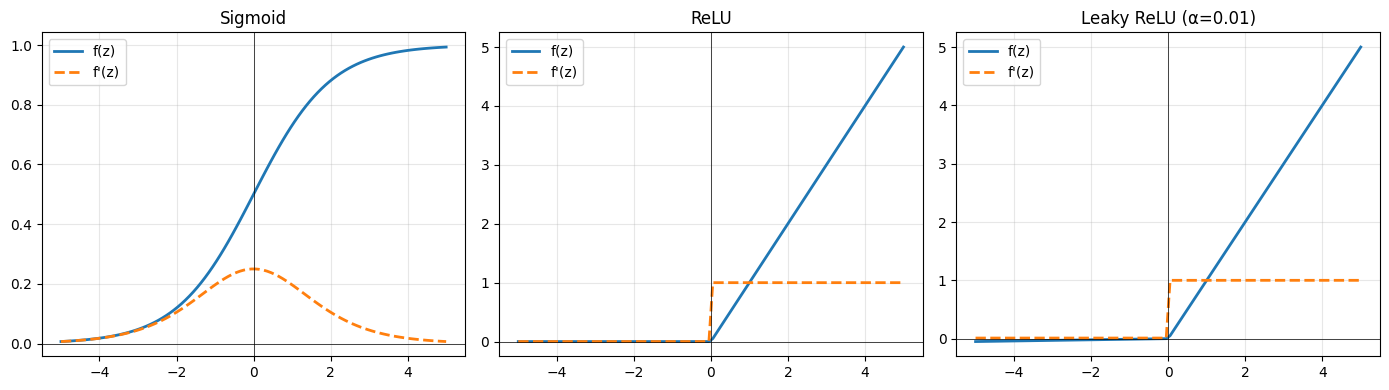

In [20]:
Z_test = np.linspace(-5, 5, 100).reshape(1, -1)
sig = Sigmoid(); relu = ReLU(); lrelu = LeakyReLU()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
activations = [(sig, 'Sigmoid'), (relu, 'ReLU'), (lrelu, 'Leaky ReLU (α=0.01)')]

for ax, (act, name) in zip(axes, activations):
    A = act.forward(Z_test)
    dZ = act.backward(np.ones_like(A))
    ax.plot(Z_test.flatten(), A.flatten(), label='f(z)', linewidth=2)
    ax.plot(Z_test.flatten(), dZ.flatten(), label="f'(z)", linewidth=2, linestyle='--')
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/activations.png', dpi=150, bbox_inches='tight')
plt.show()

## Loss Functions

In [21]:
class CrossEntropyLoss:
    def forward(self, A, Y):
        A_clipped = np.clip(A, 1e-15, 1 - 1e-15)
        batch_size = Y.shape[0]
        loss = -np.sum(Y * np.log(A_clipped)) / batch_size
        return loss

    def backward(self, A, Y):
        batch_size = Y.shape[0]
        return (A - Y) / batch_size


In [22]:
class MSELoss:
    def forward(self, A, Y):
        return np.mean((A - Y) ** 2)

    def backward(self, A, Y):
        batch_size = Y.shape[0]
        return 2 * (A - Y) / batch_size

In [ ]:
# Verify loss
A_dummy = np.array([[0.7, 0.2, 0.1], [0.1, 0.8, 0.1]])
Y_dummy = np.array([[1, 0, 0], [0, 1, 0]])
loss_fn = CrossEntropyLoss()
print(f"Test loss: {loss_fn.forward(A_dummy, Y_dummy):.4f}")
# Expected: -( log(0.7) + log(0.8) ) / 2 ≈ 0.223
print(f"Expected: {-(np.log(0.7) + np.log(0.8))/2:.4f}")

Test loss: 0.2899
Expected: 0.2899


##  Layer Class

In [24]:
class DenseLayer:
    def __init__(self, n_inputs, n_neurons, activation, 
                 init='he', l2_lambda=0.0):
        """
        n_inputs:   number of input features
        n_neurons:  number of neurons in this layer
        activation: activation object (ReLU, Sigmoid, Softmax)
        init:       'he', 'xavier', 'random', 'zeros'
        l2_lambda:  L2 regularization strength
        """
        self.activation = activation
        self.l2_lambda = l2_lambda
        self.n_inputs = n_inputs
        self.n_neurons = n_neurons

        # Weight initialization — choice matters enormously
        if init == 'he':
            # For ReLU: std = sqrt(2/n_in)
            self.W = np.random.randn(n_inputs, n_neurons) * np.sqrt(2.0 / n_inputs)
        elif init == 'xavier':
            # For sigmoid/tanh: std = sqrt(2/(n_in + n_out))
            self.W = np.random.randn(n_inputs, n_neurons) * np.sqrt(2.0 / (n_inputs + n_neurons))
        elif init == 'random':
            self.W = np.random.randn(n_inputs, n_neurons) * 0.01
        elif init == 'zeros':
            self.W = np.zeros((n_inputs, n_neurons))

        self.b = np.zeros((1, n_neurons))

        # Gradient storage (filled during backward)
        self.dW = None
        self.db = None

    def forward(self, A_prev):
        """
        A_prev: (batch_size × n_inputs)
        Returns A: (batch_size × n_neurons)
        """
        self.A_prev = A_prev                          # cache for backward
        self.Z = A_prev @ self.W + self.b             # linear transform
        self.A = self.activation.forward(self.Z)      # activation
        return self.A

    def backward(self, dA):
        """
        dA: gradient of loss w.r.t. this layer's output A
        Returns dA_prev: gradient to pass to previous layer
        """
        batch_size = self.A_prev.shape[0]

        # Gradient through activation
        dZ = self.activation.backward(dA)             # (batch × n_neurons)

        # Gradient w.r.t. weights — derived in Day 1
        self.dW = self.A_prev.T @ dZ / batch_size     # (n_inputs × n_neurons)

        # L2 regularization gradient: λW
        self.dW += self.l2_lambda * self.W

        # Gradient w.r.t. bias
        self.db = np.sum(dZ, axis=0, keepdims=True) / batch_size  # (1 × n_neurons)

        # Gradient to propagate to previous layer
        dA_prev = dZ @ self.W.T                       # (batch × n_inputs)

        return dA_prev

    def update(self, lr):
        """Vanilla SGD update"""
        self.W -= lr * self.dW
        self.b -= lr * self.db

In [25]:
class NeuralNetwork:
    def __init__(self):
        self.layers = []
        self.loss_fn = CrossEntropyLoss()
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []

    def add(self, layer):
        self.layers.append(layer)

    def forward(self, X):
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A

    def backward(self, A_out, Y):
        # Combined softmax + cross-entropy gradient
        # Note: last layer uses Softmax activation
        # The combined gradient is (A_out - Y) / batch_size
        # We pass this directly as dA to the last layer's backward
        # BUT: last layer's activation.backward will be called inside layer.backward
        # So we need to handle this carefully

        # For softmax+CE combined gradient:
        dA = self.loss_fn.backward(A_out, Y)

        # Propagate backward through layers in reverse
        # For the output layer with softmax, dA is already the combined gradient
        # We bypass the activation.backward of softmax and pass dA directly as dZ

        # Simplest approach: set softmax backward to return its input unchanged
        # (because we already have the combined gradient from loss.backward)
        for layer in reversed(self.layers):
            dA = layer.backward(dA)

    def update(self, lr):
        for layer in self.layers:
            layer.update(lr)

    def compute_accuracy(self, X, Y):
        A_out = self.forward(X)
        predictions = np.argmax(A_out, axis=1)
        targets = np.argmax(Y, axis=1)
        return np.mean(predictions == targets)

    def train(self, X_train, Y_train, X_val, Y_val,
              epochs=50, lr=0.1, batch_size=256, verbose=True):

        n_samples = X_train.shape[0]
        n_batches = int(np.ceil(n_samples / batch_size))

        for epoch in range(epochs):
            # Shuffle training data each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            Y_shuffled = Y_train[indices]

            epoch_loss = 0.0

            # Mini-batch training
            for batch_idx in range(n_batches):
                start = batch_idx * batch_size
                end = min(start + batch_size, n_samples)

                X_batch = X_shuffled[start:end]
                Y_batch = Y_shuffled[start:end]

                # Forward pass
                A_out = self.forward(X_batch)

                # Compute batch loss
                batch_loss = self.loss_fn.forward(A_out, Y_batch)
                epoch_loss += batch_loss

                # Backward pass
                self.backward(A_out, Y_batch)

                # Update weights
                self.update(lr)

            # Record metrics
            avg_loss = epoch_loss / n_batches
            val_loss = self.loss_fn.forward(self.forward(X_val), Y_val)
            train_acc = self.compute_accuracy(X_train[:5000], Y_train[:5000])
            val_acc   = self.compute_accuracy(X_val, Y_val)

            self.train_losses.append(avg_loss)
            self.val_losses.append(val_loss)
            self.train_accs.append(train_acc)
            self.val_accs.append(val_acc)

            if verbose and (epoch % 5 == 0 or epoch == epochs-1):
                print(f"Epoch {epoch+1:3d}/{epochs} | "
                      f"Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f} | "
                      f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        return self

In [26]:
import os
os.makedirs('results', exist_ok=True)

np.random.seed(42)

# Architecture: 784 → 128 → 64 → 10
# This is a standard baseline for MNIST
model = NeuralNetwork()
model.add(DenseLayer(784, 128, ReLU(),     init='he'))
model.add(DenseLayer(128, 64,  ReLU(),     init='he'))
model.add(DenseLayer(64,  10,  Softmax(),  init='xavier'))

print("Model architecture:")
print("  Input:   784 (28×28 pixels)")
print("  Layer 1: 784 → 128, ReLU, He init")
print("  Layer 2: 128 → 64,  ReLU, He init")
print("  Layer 3: 64  → 10,  Softmax, Xavier init")
print(f"\nTotal parameters: {784*128 + 128 + 128*64 + 64 + 64*10 + 10:,}")

print("\nTraining...")
model.train(
    X_train, Y_train,
    X_val,   Y_val,
    epochs=50,
    lr=0.1,
    batch_size=256,
    verbose=True
)

# Final evaluation
test_acc = model.compute_accuracy(X_test, Y_test)
print(f"\nFinal Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Model architecture:
  Input:   784 (28×28 pixels)
  Layer 1: 784 → 128, ReLU, He init
  Layer 2: 128 → 64,  ReLU, He init
  Layer 3: 64  → 10,  Softmax, Xavier init

Total parameters: 109,386

Training...


KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(model.train_losses) + 1)

# Loss curves
axes[0].plot(epochs_range, model.train_losses, label='Train loss', linewidth=2)
axes[0].plot(epochs_range, model.val_losses,   label='Val loss',   linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_range, [a*100 for a in model.train_accs], label='Train acc', linewidth=2)
axes[1].plot(epochs_range, [a*100 for a in model.val_accs],   label='Val acc',   linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best Val Accuracy: {max(model.val_accs)*100:.2f}% at epoch {np.argmax(model.val_accs)+1}")
print(f"Best Val Loss:     {min(model.val_losses):.4f} at epoch {np.argmin(model.val_losses)+1}")